# Example notebook for ABM analyses

This notebook provides example code to extract data from and conduct analyses on ABM outputs. The simulation data needed for this notebook to run properly is not currently uploaded to GitHub, but will be in the future. A different notebook contains the complete code needed to reproduce the figures in [PAPER]. 

The installation of functions & constants for the analysis will eventually be done via package installation, but is not currently configured for such a set-up.

In [1]:
import sys
import os

# Import custom functions (will convert to package install @ later date
sys.path.append('/project2/sfinley_500/tking/abm_testing/breast_cancer/python/src')
from analyzeABM import *

# Set this path to wherever the simulation data is located
path_to_simulations = "/project2/sfinley_500/tking/abm_testing/breast_cancer" 

## Retrieving and analyzing data from a single metastasis

In [2]:
# Let's look at one met
met = 107

# This is the path to all non-tx results for this met
path_notx = os.path.join(path_to_simulations, "simulations_may2026", f"mIHC_{met}")

# This is the path to all tx results for this met
path_tx = os.path.join(path_to_simulations, "simulations_may2026", f"mIHC_{met}_tx")

# Now, we can read in all the data for each case
met_notx = retrieve_ts(path_notx, num_replicates=25)
met_tx = retrieve_ts(path_tx, num_replicates=25)

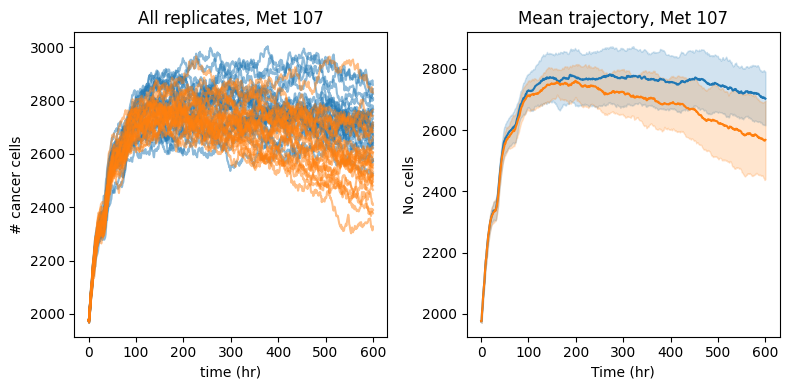

In [3]:
# We can then, for example, plot the cancer time series data for all replicates
fig, ax = plt.subplots(1, 2, figsize=(8, 4), dpi=100)

# Here, we can use the DF directly to plot each replicate's TS data
met_notx["c"].plot(legend=False, ax=ax[0], color='tab:blue', alpha=0.5)
met_tx["c"].plot(legend=False, ax=ax[0], color='tab:orange', alpha=0.5)
ax[0].set(xlabel="time (hr)", ylabel="# cancer cells", title=f"All replicates, Met {met}")

# We can also use our visualization built-in functions to plot this with some processing
# This allows us to see the avg +/- one standard deviation
plot_ts(met_notx, types_to_plot=["c"], title=f"Mean trajectory, Met {met}", ax=ax[1])
plot_ts(met_tx, types_to_plot=["c"], title=f"Mean trajectory, Met {met}", ax=ax[1])

fig.tight_layout()

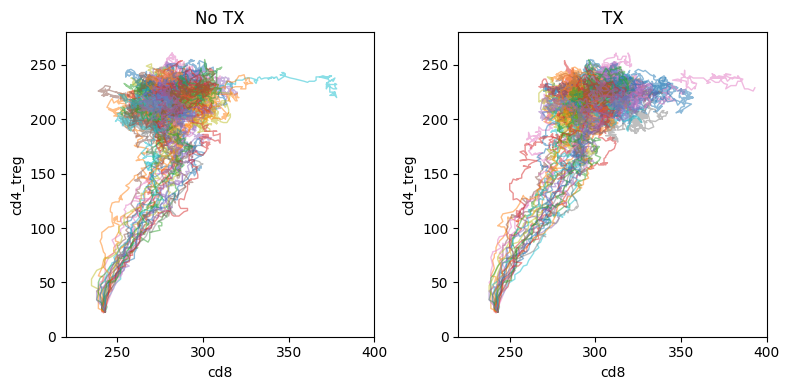

In [5]:
# We can also use the DFs directly to make other plots
# For example, we can look at the phase-space trajectories in terms of two cell populations

ctype1 = "cd8"
ctype2 = "cd4_treg"

xlim = [220, 400]
ylim = [0, 280]

fig, ax = plt.subplots(1, 2, figsize=(8, 4), dpi=100)
for i in range(25):
    ax[0].plot(met_notx[ctype1][str(i)], met_notx[ctype2][str(i)], lw=1, alpha=0.5)
    ax[1].plot(met_tx[ctype1][str(i)], met_notx[ctype2][str(i)], lw=1, alpha=0.5)

ax[0].set(xlabel=ctype1, ylabel=ctype2, title="No TX", xlim=xlim, ylim=ylim)
ax[1].set(xlabel=ctype1, ylabel=ctype2, title="TX", xlim=xlim, ylim=ylim)

fig.tight_layout()

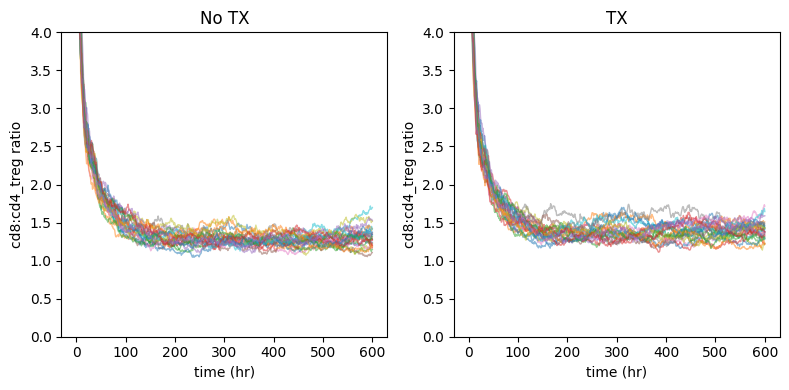

In [6]:
# Or we could consider their ratio over time

fig, ax = plt.subplots(1, 2, figsize=(8, 4), dpi=100)
for i in range(25):
    ax[0].plot(met_notx[ctype1][str(i)] / met_notx[ctype2][str(i)], lw=1, alpha=0.5)
    ax[1].plot(met_tx[ctype1][str(i)] / met_notx[ctype2][str(i)], lw=1, alpha=0.5)

ax[0].set(xlabel="time (hr)", ylabel=f"{ctype1}:{ctype2} ratio", title="No TX", ylim=(0, 4))
ax[1].set(xlabel="time (hr)", ylabel=f"{ctype1}:{ctype2} ratio", title="TX", ylim=(0, 4))

fig.tight_layout()

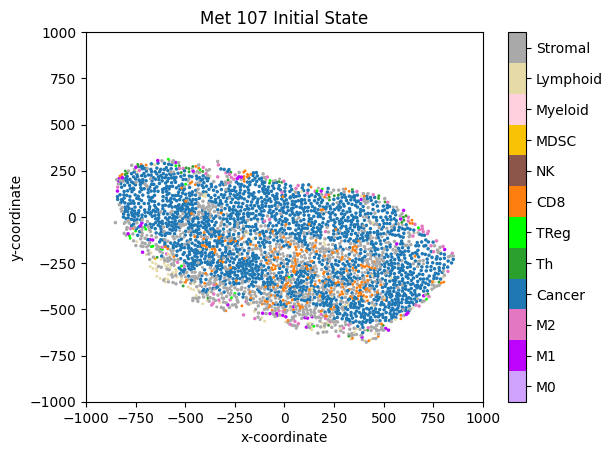

In [7]:
# If we wanted to see what the met looks like initially, then we can also plot this
met_ic = os.path.join(path_notx, "set_0", "cellLists", "day_0", "cells.csv")
fig = plot_celldata(met_ic, title=f"Met {met} Initial State")
fig.set_dpi(100) # Default is 300 DPI